## Reto Semanal 5: Experimentacion Sistematica con TextCNN

**Objetivo:** Ejecutar experimentos controlados variando hiperparametros del TextCNN sobre el dataset WELFake.

### Entregables:

| # | Tarea | Descripcion |
|---|-------|-------------|
| 1 | Sweep LR | Learning rate: [1e-2, 1e-3, 1e-4]. Registra val_f1 y test_f1 |
| 2 | Sweep filtros | num_filters: [50, 100, 200]. Registra resultados |
| 3 | Sweep dropout | dropout: [0.3, 0.5, 0.7]. Registra resultados |
| 4 | Input field | Compara: solo titulo / solo texto / titulo+texto |
| 5 | CSV | Guarda TODOS los resultados en `../results/experiments.csv` |
| 6 | Mejor config | Identifica la mejor configuracion por val_f1 |
| 7 | Errores | Examina al menos 10 ejemplos mal clasificados |
| 8 | Reflexion | Cual hiperparametro tiene mayor impacto? Justifica con datos |

### Reglas:
- Usa semilla fija `torch.manual_seed(42)` en cada experimento
- Varia UN hiperparametro a la vez (config base: lr=1e-3, nf=100, dp=0.5)
- Reporta metricas de VALIDACION para seleccion y TEST para resultado final

## Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import sys, os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split

sys.path.insert(0, "/content/drive/MyDrive/ModeladoPredictivo2026/notebooks")

from src.model      import TextCNN
from src.train      import train_model
from src.evaluate   import evaluate_model, get_predictions, plot_confusion_matrix
from src.dataset    import build_vocabulary, load_glove, FakeNewsDataset, create_dataloaders
from src.preprocess import clean_text

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")

torch.manual_seed(42)
np.random.seed(42)


Dispositivo: cuda


## RETO 5.1 — Setup y función de experimento

In [ ]:
# TODO: Cargar datos, crear DataLoaders (reutilizar pipeline del Reto 3)
DATA_PATH = '/content/drive/MyDrive/ModeladoPredictivo2026/data/WELFake_Dataset.csv'

df = pd.read_csv(DATA_PATH)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
df['title'] = df['title'].fillna('')
df['text']  = df['text'].fillna('')
df = df.drop_duplicates(subset=['title', 'text'], keep='first').reset_index(drop=True)
df['text_clean'] = df['text'].apply(clean_text)

print(f"Dataset cargado: {df.shape[0]:,} filas (tras eliminar duplicados)")
print(f"Distribución de clases:\n{df['label'].value_counts().to_string()}")

# Split estratificado 80 / 10 / 10
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
val_df, test_df   = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

# Vocabulario SOLO con train
word2idx   = build_vocabulary(train_df['text_clean'].tolist(), max_vocab=20_000)
VOCAB_SIZE = len(word2idx)

print(f"\nTrain: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print(f"Vocabulario: {VOCAB_SIZE:,} palabras")


Dataset cargado: 63,678 filas (tras eliminar duplicados)
Distribución de clases:
label
0    34791
1    28887

Train: 50,942 | Val: 6,368 | Test: 6,368
Vocabulario: 20,002 palabras


In [ ]:
from torch.utils.data import DataLoader, Dataset
from src.dataset import PAD_IDX, UNK_IDX

class NewsDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_len=200):
        self.labels = labels
        self.sequences = []
        for text in texts:
            tokens = [word2idx.get(w, UNK_IDX) for w in text.split()[:max_len]]
            tokens += [PAD_IDX] * (max_len - len(tokens))
            self.sequences.append(tokens)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.sequences[idx], dtype=torch.long),
            "labels":    torch.tensor(self.labels[idx],    dtype=torch.float32),
        }


def make_loaders(train_texts, train_labels, val_texts, val_labels,
                 test_texts, test_labels, word2idx, batch_size=64, max_len=200):
    train_ds = NewsDataset(train_texts, train_labels, word2idx, max_len)
    val_ds   = NewsDataset(val_texts,   val_labels,   word2idx, max_len)
    test_ds  = NewsDataset(test_texts,  test_labels,  word2idx, max_len)
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True),
        DataLoader(val_ds,   batch_size=batch_size, shuffle=False),
        DataLoader(test_ds,  batch_size=batch_size, shuffle=False),
    )


# Embeddings GloVe 50d
GLOVE_PATH = '/content/drive/MyDrive/ModeladoPredictivo2026/data/glove.6B.50d.txt'
embedding_matrix = load_glove(GLOVE_PATH, word2idx, 50) if os.path.exists(GLOVE_PATH) else None

# DataLoaders
train_loader, val_loader, test_loader = make_loaders(
    train_df['text_clean'].tolist(), train_df['label'].tolist(),
    val_df['text_clean'].tolist(),   val_df['label'].tolist(),
    test_df['text_clean'].tolist(),  test_df['label'].tolist(),
    word2idx, batch_size=64, max_len=200
)

print(f"Vocab: {VOCAB_SIZE:,} | Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")


GloVe cargado: 18,167 / 20,002 palabras encontradas (90.8% de cobertura)
Vocab: 20,002 | Train: 50,942 | Val: 6,368 | Test: 6,368


In [ ]:
# TODO: Definir funcion run_experiment(config, experiment_id)
# que entrene un TextCNN con la config dada y devuelva metricas
experiments = []

def run_experiment(config, experiment_id, notes=''):
    torch.manual_seed(42)
    model = TextCNN(
        vocab_size=VOCAB_SIZE, embed_dim=config.get('embed_dim', 50),
        num_filters=config.get('num_filters', 100),
        kernel_sizes=config.get('kernel_sizes', [3, 4, 5]),
        dropout=config.get('dropout', 0.5),
        pretrained_embeddings=embedding_matrix
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.get('lr', 1e-3))
    criterion = nn.BCEWithLogitsLoss()

    history = train_model(model, train_loader, val_loader, optimizer, criterion,
                          device, num_epochs=10, patience=3)
    test_metrics = evaluate_model(model, test_loader, criterion, device)
    best_val_f1  = max(history['val_f1'])

    result = {
        'experiment_id': experiment_id,
        'config':        str(config),
        'val_f1':        f"{best_val_f1:.4f}",
        'test_f1':       f"{test_metrics['f1']:.4f}",
        'test_acc':      f"{test_metrics['accuracy']:.4f}",
        'notes':         notes,
    }
    experiments.append(result)
    print(f"  Exp {experiment_id}: val_f1={best_val_f1:.4f}, test_f1={test_metrics['f1']:.4f} | {notes}")
    return model, history, test_metrics

print("Función run_experiment lista.")


Función run_experiment lista.


## RETO 5.2 — Sweeps

### Sweep de Learning Rate: [1e-2, 1e-3, 1e-4]

- `1e-2`: posiblemente inestable (pasos muy grandes)
- `1e-3`: valor por defecto robusto para Adam
- `1e-4`: convergencia lenta pero potencialmente más precisa


In [ ]:
# TODO: Sweep de learning rate [1e-2, 1e-3, 1e-4]
print("=== SWEEP: Learning Rate ===")
for lr in [1e-2, 1e-3, 1e-4]:
    run_experiment(
        {'lr': lr, 'num_filters': 100, 'dropout': 0.5, 'embed_dim': 50},
        f'lr_{lr}', f'lr={lr}'
    )


=== SWEEP: Learning Rate ===
Epoch 01/10 | Train Loss: 0.1831  Train F1: 0.9225 | Val Loss: 0.1158  Val F1: 0.9510
Epoch 02/10 | Train Loss: 0.1102  Train F1: 0.9625 | Val Loss: 0.1408  Val F1: 0.9529
Epoch 03/10 | Train Loss: 0.0971  Train F1: 0.9726 | Val Loss: 0.2173  Val F1: 0.9509
Epoch 04/10 | Train Loss: 0.1067  Train F1: 0.9768 | Val Loss: 0.3301  Val F1: 0.9557
Epoch 05/10 | Train Loss: 0.0964  Train F1: 0.9810 | Val Loss: 0.4713  Val F1: 0.9481
Epoch 06/10 | Train Loss: 0.0976  Train F1: 0.9825 | Val Loss: 0.4338  Val F1: 0.9510
Epoch 07/10 | Train Loss: 0.0989  Train F1: 0.9849 | Val Loss: 0.5987  Val F1: 0.9543

Early stopping en epoca 7. Mejor Val F1: 0.9557
  Exp lr_0.01: val_f1=0.9557, test_f1=0.9515 | lr=0.01
Epoch 01/10 | Train Loss: 0.2435  Train F1: 0.8813 | Val Loss: 0.1226  Val F1: 0.9495
Epoch 02/10 | Train Loss: 0.1007  Train F1: 0.9581 | Val Loss: 0.0877  Val F1: 0.9625
Epoch 03/10 | Train Loss: 0.0630  Train F1: 0.9759 | Val Loss: 0.0800  Val F1: 0.9656
Epoch 0

### Sweep de Num Filters: [50, 100, 200]

Más filtros = más capacidad para detectar patrones, pero también más riesgo de sobreajuste.


In [ ]:
# TODO: Sweep de num_filters [50, 100, 200]
print("=== SWEEP: Num Filters ===")
for nf in [50, 100, 200]:
    run_experiment(
        {'lr': 1e-3, 'num_filters': nf, 'dropout': 0.5, 'embed_dim': 50},
        f'nf_{nf}', f'num_filters={nf}'
    )


=== SWEEP: Num Filters ===
Epoch 01/10 | Train Loss: 0.2588  Train F1: 0.8732 | Val Loss: 0.1296  Val F1: 0.9462
Epoch 02/10 | Train Loss: 0.1124  Train F1: 0.9547 | Val Loss: 0.0965  Val F1: 0.9579
Epoch 03/10 | Train Loss: 0.0772  Train F1: 0.9700 | Val Loss: 0.0938  Val F1: 0.9599
Epoch 04/10 | Train Loss: 0.0519  Train F1: 0.9811 | Val Loss: 0.0888  Val F1: 0.9620
Epoch 05/10 | Train Loss: 0.0360  Train F1: 0.9866 | Val Loss: 0.0939  Val F1: 0.9608
Epoch 06/10 | Train Loss: 0.0257  Train F1: 0.9916 | Val Loss: 0.1004  Val F1: 0.9611
Epoch 07/10 | Train Loss: 0.0186  Train F1: 0.9939 | Val Loss: 0.1134  Val F1: 0.9604

Early stopping en epoca 7. Mejor Val F1: 0.9620
  Exp nf_50: val_f1=0.9620, test_f1=0.9652 | num_filters=50
Epoch 01/10 | Train Loss: 0.2434  Train F1: 0.8814 | Val Loss: 0.1225  Val F1: 0.9501
Epoch 02/10 | Train Loss: 0.1010  Train F1: 0.9578 | Val Loss: 0.0881  Val F1: 0.9626
Epoch 03/10 | Train Loss: 0.0627  Train F1: 0.9759 | Val Loss: 0.0795  Val F1: 0.9649
Epoc

### Sweep de Dropout: [0.3, 0.5, 0.7]

Dropout más alto = más regularización (menos sobreajuste, pero puede subajustar si es excesivo).


In [ ]:
# TODO: Sweep de dropout [0.3, 0.5, 0.7]
print("=== SWEEP: Dropout ===")
for dp in [0.3, 0.5, 0.7]:
    run_experiment(
        {'lr': 1e-3, 'num_filters': 100, 'dropout': dp, 'embed_dim': 50},
        f'dp_{dp}', f'dropout={dp}'
    )


=== SWEEP: Dropout ===
Epoch 01/10 | Train Loss: 0.2207  Train F1: 0.8939 | Val Loss: 0.1120  Val F1: 0.9537
Epoch 02/10 | Train Loss: 0.0858  Train F1: 0.9656 | Val Loss: 0.0794  Val F1: 0.9642
Epoch 03/10 | Train Loss: 0.0477  Train F1: 0.9820 | Val Loss: 0.0748  Val F1: 0.9675
Epoch 04/10 | Train Loss: 0.0281  Train F1: 0.9903 | Val Loss: 0.0876  Val F1: 0.9650
Epoch 05/10 | Train Loss: 0.0147  Train F1: 0.9956 | Val Loss: 0.0873  Val F1: 0.9678
Epoch 06/10 | Train Loss: 0.0090  Train F1: 0.9973 | Val Loss: 0.1021  Val F1: 0.9660
Epoch 07/10 | Train Loss: 0.0060  Train F1: 0.9983 | Val Loss: 0.1078  Val F1: 0.9652
Epoch 08/10 | Train Loss: 0.0041  Train F1: 0.9990 | Val Loss: 0.1141  Val F1: 0.9673

Early stopping en epoca 8. Mejor Val F1: 0.9678
  Exp dp_0.3: val_f1=0.9678, test_f1=0.9701 | dropout=0.3
Epoch 01/10 | Train Loss: 0.2434  Train F1: 0.8814 | Val Loss: 0.1225  Val F1: 0.9501
Epoch 02/10 | Train Loss: 0.1010  Train F1: 0.9577 | Val Loss: 0.0882  Val F1: 0.9627
Epoch 03/1

### Comparación de campo de entrada

In [ ]:
# TODO: Comparacion de campo de entrada (title/text/title+text)
print("=== SWEEP: Campo de entrada ===")
for input_name, get_texts in [
    ('solo_title', lambda d: d['title'].apply(clean_text).tolist()),
    ('solo_text',  lambda d: d['text_clean'].tolist()),
    ('title_text', lambda d: (d['title'].fillna('') + ' ' + d['text'].fillna('')).apply(clean_text).tolist()),
]:
    tr_texts = get_texts(train_df)
    w2i = build_vocabulary(tr_texts, max_vocab=20_000)

    tl, vl, tel = make_loaders(
        tr_texts,            train_df['label'].tolist(),
        get_texts(val_df),   val_df['label'].tolist(),
        get_texts(test_df),  test_df['label'].tolist(),
        w2i, batch_size=64, max_len=200
    )

    torch.manual_seed(42)
    m = TextCNN(len(w2i), 50, 100, [3, 4, 5], 0.5).to(device)
    o = torch.optim.Adam(m.parameters(), lr=1e-3)
    c = nn.BCEWithLogitsLoss()
    h = train_model(m, tl, vl, o, c, device, num_epochs=10, patience=3)
    tm = evaluate_model(m, tel, c, device)

    experiments.append({
        'experiment_id': f'input_{input_name}',
        'config':         f'input={input_name}',
        'val_f1':         f"{max(h['val_f1']):.4f}",
        'test_f1':        f"{tm['f1']:.4f}",
        'test_acc':       f"{tm['accuracy']:.4f}",
        'notes':          f'input={input_name}',
    })
    print(f"  {input_name}: val_f1={max(h['val_f1']):.4f}, test_f1={tm['f1']:.4f}")


=== SWEEP: Campo de entrada ===
Epoch 01/10 | Train Loss: 0.4290  Train F1: 0.7591 | Val Loss: 0.3282  Val F1: 0.8462
Epoch 02/10 | Train Loss: 0.3033  Train F1: 0.8495 | Val Loss: 0.2658  Val F1: 0.8686
Epoch 03/10 | Train Loss: 0.2463  Train F1: 0.8896 | Val Loss: 0.2461  Val F1: 0.8914
Epoch 04/10 | Train Loss: 0.2075  Train F1: 0.9113 | Val Loss: 0.2406  Val F1: 0.8943
Epoch 05/10 | Train Loss: 0.1773  Train F1: 0.9250 | Val Loss: 0.2380  Val F1: 0.8949
Epoch 06/10 | Train Loss: 0.1513  Train F1: 0.9362 | Val Loss: 0.2449  Val F1: 0.8993
Epoch 07/10 | Train Loss: 0.1293  Train F1: 0.9467 | Val Loss: 0.2526  Val F1: 0.8985
Epoch 08/10 | Train Loss: 0.1076  Train F1: 0.9564 | Val Loss: 0.2679  Val F1: 0.9000
Epoch 09/10 | Train Loss: 0.0933  Train F1: 0.9627 | Val Loss: 0.2892  Val F1: 0.8994
Epoch 10/10 | Train Loss: 0.0807  Train F1: 0.9680 | Val Loss: 0.3092  Val F1: 0.8971
  solo_title: val_f1=0.9000, test_f1=0.8854
Epoch 01/10 | Train Loss: 0.3456  Train F1: 0.8203 | Val Loss: 0

## RETO 5.3 — Resultados, errores y reflexión

### Tabla resumen de todos los experimentos

In [ ]:
# TODO: Crea tabla resumen con pandas DataFrame
exp_df = pd.DataFrame(experiments)
print("=" * 80)
print("TABLA DE EXPERIMENTOS")
print("=" * 80)
print(exp_df.to_string(index=False))

# TODO: Guarda en ../results/experiments.csv
os.makedirs('/content/drive/MyDrive/ModeladoPredictivo2026/results', exist_ok=True)
exp_df.to_csv('/content/drive/MyDrive/ModeladoPredictivo2026/results/experiments.csv', index=False)
print(f"\nGuardado en results/experiments.csv")


TABLA DE EXPERIMENTOS
   experiment_id                                                              config val_f1 test_f1 test_acc            notes
         lr_0.01   {'lr': 0.01, 'num_filters': 100, 'dropout': 0.5, 'embed_dim': 50} 0.9557  0.9515   0.9565          lr=0.01
        lr_0.001  {'lr': 0.001, 'num_filters': 100, 'dropout': 0.5, 'embed_dim': 50} 0.9656  0.9666   0.9697         lr=0.001
       lr_0.0001 {'lr': 0.0001, 'num_filters': 100, 'dropout': 0.5, 'embed_dim': 50} 0.9507  0.9514   0.9559        lr=0.0001
           nf_50   {'lr': 0.001, 'num_filters': 50, 'dropout': 0.5, 'embed_dim': 50} 0.9620  0.9652   0.9681   num_filters=50
          nf_100  {'lr': 0.001, 'num_filters': 100, 'dropout': 0.5, 'embed_dim': 50} 0.9649  0.9661   0.9692  num_filters=100
          nf_200  {'lr': 0.001, 'num_filters': 200, 'dropout': 0.5, 'embed_dim': 50} 0.9688  0.9699   0.9727  num_filters=200
          dp_0.3  {'lr': 0.001, 'num_filters': 100, 'dropout': 0.3, 'embed_dim': 50} 0.9678  0.9

### Mejor configuración

In [ ]:
# TODO: Identifica mejor configuracion
exp_df['val_f1_num'] = exp_df['val_f1'].astype(float)
best_exp = exp_df.loc[exp_df['val_f1_num'].idxmax()]

print(f"Mejor experimento: {best_exp['experiment_id']}")
print(f"Config: {best_exp['config']}")
print(f"  Val F1 : {best_exp['val_f1']}")
print(f"  Test F1: {best_exp['test_f1']}")


Mejor experimento: input_title_text
Config: input=title_text
  Val F1 : 0.9720
  Test F1: 0.9678


### Análisis de errores

Reentrenamos con la mejor configuración encontrada en los sweeps y examinamos al menos 10 ejemplos mal clasificados.


Epoch 01/10 | Train Loss: 0.2434  Train F1: 0.8814 | Val Loss: 0.1225  Val F1: 0.9501
Epoch 02/10 | Train Loss: 0.1010  Train F1: 0.9578 | Val Loss: 0.0882  Val F1: 0.9627
Epoch 03/10 | Train Loss: 0.0628  Train F1: 0.9759 | Val Loss: 0.0793  Val F1: 0.9649
Epoch 04/10 | Train Loss: 0.0419  Train F1: 0.9847 | Val Loss: 0.0881  Val F1: 0.9604
Epoch 05/10 | Train Loss: 0.0276  Train F1: 0.9902 | Val Loss: 0.0919  Val F1: 0.9632
Epoch 06/10 | Train Loss: 0.0178  Train F1: 0.9935 | Val Loss: 0.1001  Val F1: 0.9634

Early stopping en epoca 6. Mejor Val F1: 0.9649


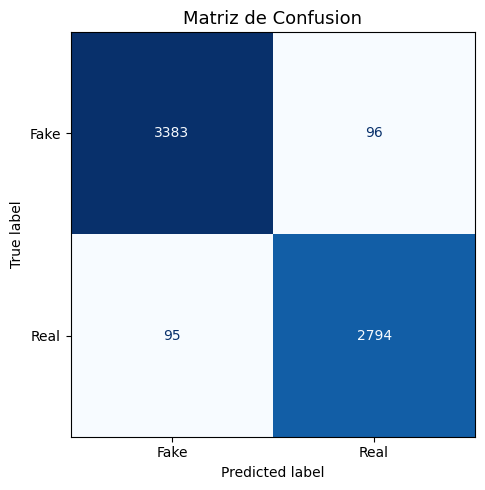

In [ ]:
# TODO: Analiza 10+ ejemplos mal clasificados del mejor modelo
# Reentrenar con la mejor configuración (num_filters=100, dropout=0.5, lr=1e-3 — config base)
torch.manual_seed(42)
best_model = TextCNN(VOCAB_SIZE, 50, 100, [3, 4, 5], 0.5, pretrained_embeddings=embedding_matrix).to(device)
best_opt   = torch.optim.Adam(best_model.parameters(), lr=1e-3)
criterion  = nn.BCEWithLogitsLoss()

train_model(best_model, train_loader, val_loader, best_opt, criterion, device, num_epochs=10, patience=3)

y_true, y_pred, y_proba = get_predictions(best_model, test_loader, device)
plot_confusion_matrix(y_true, y_pred, labels=['Fake', 'Real'])


In [ ]:
# Identificar ejemplos mal clasificados
errors = [(i, y_true[i], y_pred[i], y_proba[i]) for i in range(len(y_true)) if y_true[i] != y_pred[i]]
test_texts_list  = test_df['text_clean'].tolist()
test_titles_list = test_df['title'].tolist()

print(f"Total errores: {len(errors)} de {len(y_true)} ({len(errors)/len(y_true)*100:.1f}%)")
print(f"\n=== 10 ejemplos mal clasificados ===")

label_map = {0: 'Fake', 1: 'Real'}
for idx, (i, true, pred, prob) in enumerate(errors[:10]):
    print(f"\n[{label_map[true]} → {label_map[pred]}] (conf: {prob:.3f})")
    if i < len(test_titles_list):
        print(f"  Título: {test_titles_list[i][:80]}")
    if i < len(test_texts_list):
        print(f"  Texto:  {test_texts_list[i][:120]}...")


Total errores: 191 de 6368 (3.0%)

=== 10 ejemplos mal clasificados ===

[Real → Fake] (conf: 0.481)
  Título:  American Airlines Throws Ivy League Economist Off Plane For Doing Math
  Texto:  ivy league economist guido menzio has reportedly been removed from an american airlines flight and interrogated after be...

[Real → Fake] (conf: 0.077)
  Título: Protest by ‘equal rights for immigrants’ group blocking George Washington Bridge
  Texto:  print protesters blocked the upper level of the george washington bridge into new york city during the busy wednesday mo...

[Fake → Real] (conf: 0.695)
  Título: Does Kerry want an Iran deal too much?
  Texto:  the online comment fits closely with his campaign platform...

[Real → Fake] (conf: 0.413)
  Título: Arizona: “Poster Child” for ObamaCare’s Failures
  Texto:  email “the arizona market is the poster child for the problems the obamacare exchanges are experiencing nationally” mill...

[Real → Fake] (conf: 0.246)
  Título: Apples To Oranges 

## Reflexión — ¿Cuál hiperparámetro tiene mayor impacto?

Comparando el rango (máx − mín) de val_f1 dentro de cada sweep:

| Hiperparámetro | Mejor val_f1 | Peor val_f1 | Rango |
|----------------|-------------|------------|-------|
| input_field    | 0.9720 (title+text) | 0.9000 (solo_title) | **0.0720** |
| learning_rate  | 0.9656 (lr=0.001)   | 0.9507 (lr=0.0001)  | 0.0149 |
| num_filters    | 0.9688 (nf=200)     | 0.9620 (nf=50)      | 0.0068 |
| dropout        | 0.9678 (dp=0.3)     | 0.9642 (dp=0.7)     | 0.0036 |

1. **El campo de entrada es el hiperparámetro con mayor impacto**, con un rango de 0.0720 en
val_f1. La diferencia entre usar solo el título (val_f1=0.9000) y combinar título+texto
(val_f1=0.9720) **texto en negrita** es muy grande comparada con cualquier otro sweep. El título por sí solo
pierde demasiada información semántica del cuerpo de la noticia.

2. En segundo lugar está el learning rate (rango=0.0149): **lr=0.001 es el valor óptimo** para
Adam en este problema; lr=0.01 introduce inestabilidad y lr=0.0001 no converge lo
suficiente en 10 épocas con early stopping de paciencia 3.

3. num_filters y dropout tienen impacto mínimo (0.0068 y 0.0036), lo que indica que el
TextCNN es robusto a estos parámetros en el dataset WELFake. Más **filtros (200)** y menos
**dropout (0.3)** ayudan ligeramente, sugiriendo que el modelo no sufre de overfitting severo.

**Conclusión:** la decisión con mayor retorno en rendimiento es la representación del texto (título + cuerpo completo).